# 5. Hafta - Rastgele Başlangıç Koşullarından İstatistiksel Fiziğe

**Proje:** Hücresel Otomatlarda Beliren Karmaşıklık  
**Not defteri:** `05_random_initial_conditions.ipynb`  
**Tahmini süre:** 8-10 saat

İlk dört haftada dikkatle seçilmiş birkaç başlangıç durumunu inceledin. Bu hafta tek tek özel örneklerden **tipik davranışa** geçiyoruz.

Ana araştırma sorumuz:

> **Game of Life'ın uzun-zaman davranışı, rastgele başlangıçtaki canlı hücre olasılığı $p$'ye nasıl bağlıdır?**

Bir simülasyonda ne olabileceğini görmek yeterli değildir. Aynı $p$ değeri için farklı rastgele ızgaralar farklı sonuçlar verebilir. Bu nedenle tekrarlar, ortalamalar ve dalgalanmalar kullanacağız.

## Projede şimdiye kadar geldiğimiz nokta

### 1. hafta - Yerel kurallardan büyük ölçekli desenlere

Tek boyutlu hücresel otomat motorunu kurdun. Aynı kod yapısının sönme, fraktal, düzensiz ve karmaşık davranışlar oluşturabildiğini gördün.

### 2. hafta - Resimlerden ölçümlere

256 ECA kuralını karşılaştırdın, yoğunluk ve etkinliği tanımladın. Tek bir gözlenebilirin uzamsal yapının tamamını anlatmadığını öğrendin.

### 3. hafta - Duyarlılık ve bilgi yayılması

Tek hücrelik bir farkın kaybolmasını, yerel kalmasını veya ışık konisi içinde yayılmasını Hamming uzaklığı ve pertürbasyon yarıçapıyla ölçtün. Farklı rastgele tohumların karşılaştırılmasının önemini gördün.

### 4. hafta - İki boyut ve beliren nesneler

Game of Life'ı kurdun, still life, oscillator ve glider yapılarını yeniden ürettin. Gliderın periyodunu, yer değiştirmesini ve etkin hızını ölçtün.

### 5. haftanın rolü

Şimdi “özel olarak hazırlanmış bir glider ne yapar?” sorusundan şuna geçiyoruz:

$$
\boxed{\text{Rastgele hazırlanmış sistem tipik olarak ne yapar?}}
$$

Bu, projeyi hücresel otomat gösteriminden hesaplamalı istatistiksel fiziğe taşıyan adımdır.

## Önümüzdeki haftalar ile bağlantı

- **5. hafta:** Başlangıç yoğunluğu $p$'yi değiştir, her $p$ için çok sayıda başlangıç durumu üret, ortalama ve standart sapma hesapla.
- **6. hafta:** Modelin dinamiğine olasılıksal bir kontrol parametresi ekle. Örneğin her güncellemeden sonra canlı hücreyi $\mu$ olasılıkla öldür. Standart Life, $\mu=0$'dır.
- **7. hafta:** Sistem boyutu, pertürbasyon yayılması veya yoğunluk bağımlılığı üzerine bağımsız bir sayısal araştırma yürüt.
- **8. hafta:** Kodları, ana şekilleri ve sonuçları bilimsel bir anlatıya dönüştür.

Bu hafta değiştirilen $p$, yalnızca **başlangıç koşulunu** kontrol eder. 6. haftadaki $\mu$ veya doğum olasılığı $q$ ise sistemin **güncelleme dinamiğini** değiştirir. Bu ayrım önemlidir:

$$
\underbrace{p}_{\text{başlangıç koşulu}}
\qquad\text{ve}\qquad
\underbrace{\mu, q}_{\text{dinamik kontrol parametreleri}}.
$$

### Öğrenme hedefleri

Bu not defterinin sonunda şunları yapabilmelisin:

1. tekrarlanabilir rastgele Life ızgaraları üretmek,
2. yoğunluk ve etkinlik zaman serilerini hesaplamak,
3. tek bir son kare yerine geç-zaman ortalaması kullanmak,
4. aynı parametrede bağımsız deneyler tekrarlamak,
5. örneklem ortalaması ve standart sapmayı ayırmak,
6. $p$ taraması yapıp hata çubuklu şekiller çizmek,
7. sonlu süre ve sonlu boyut sınırlamalarını dürüstçe tartışmak.

## Model ve deney protokolü

Başlangıçta her hücre birbirinden bağımsız olarak $p$ olasılıkla canlı olsun:

$$
P(s_{ij}(0)=1)=p.
$$

Sonra standart B3/S23 Game of Life kuralını uygularız. Her $p$ için $M$ bağımsız başlangıç üretiriz.

### Deneyden önce tahmin et

1. $p$ arttıkça geç-zaman yoğunluğu sürekli artar mı?
2. $p\approx1$ olan çok yoğun bir ızgara uzun süre yoğun kalır mı?
3. En büyük deneyden-deneye değişkenliği düşük, orta veya yüksek $p$'de mi beklersin?
4. Etkinlik sıfır olduğunda nüfus da mutlaka sıfır mıdır?

**Tahminlerim:**

Bence başlangıç yoğunluğu arttıkça son yoğunluk sürekli artmayacak. İlk başta daha fazla canlı hücre olması avantaj gibi görünse de çok kalabalık olunca hücrelerin aşırı komşudan dolayı ölebileceğini düşünüyorum. Bu yüzden orta bir $p$ değerinde daha fazla canlı hücre kalabilir. $p$ değeri 1'e çok yakınsa sistemin ilk adımlarda hızlı şekilde seyrekleşmesini bekliyorum. Deneyden deneye farkın da orta yoğunluklarda daha büyük olabileceğini tahmin ediyorum, çünkü küçük başlangıç farkları farklı desenlere dönüşebilir. Etkinlik sıfır olduğunda bütün hücrelerin ölmüş olması gerekmez, değişmeden duran still life yapıları kalabilir. Sonuçlarda özellikle orta $p$ bölgesinde bir tepe olup olmadığına bakmak istiyorum.


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["image.cmap"] = "binary"


def check(label, test_function):
    '''Bir öğrenci testini not defterini durdurmadan çalıştır.'''
    try:
        test_function()
    except (AssertionError, NotImplementedError, ValueError) as error:
        message = str(error) or "sonuç beklenen değerle eşleşmedi"
        print(f"○ {label}: çalışmaya devam et — {message}")
    else:
        print(f"✓ {label}: geçti")


print("Kurulum tamamlandı.")

Kurulum tamamlandı.


## 1. Game of Life motoru

Bu hafta 4. haftada doğruladığın motoru deney aracı olarak kullanıyoruz. Periyodik sınır koşulları korunmuştur.

In [2]:
def count_neighbors(grid):
    '''Periyodik sınırlarda sekiz canlı komşuyu say.'''
    grid = np.asarray(grid, dtype=np.uint8)
    neighbors = np.zeros_like(grid, dtype=np.uint8)
    for di in (-1, 0, 1):
        for dj in (-1, 0, 1):
            if di == 0 and dj == 0:
                continue
            neighbors += np.roll(np.roll(grid, di, axis=0), dj, axis=1)
    return neighbors


def update_life(grid):
    '''B3/S23 kuralını bir adım uygula.'''
    grid = np.asarray(grid, dtype=np.uint8)
    neighbors = count_neighbors(grid)
    birth = (grid == 0) & (neighbors == 3)
    survival = (grid == 1) & ((neighbors == 2) | (neighbors == 3))
    return (birth | survival).astype(np.uint8)


def simulate_life(initial_grid, steps):
    '''Başlangıç durumu dâhil Life geçmişini döndür.'''
    initial_grid = np.asarray(initial_grid, dtype=np.uint8)
    history = np.zeros((steps, *initial_grid.shape), dtype=np.uint8)
    history[0] = initial_grid
    for t in range(1, steps):
        history[t] = update_life(history[t - 1])
    return history


assert simulate_life(np.zeros((5, 5), dtype=np.uint8), 3).shape == (3, 5, 5)
print("Game of Life motoru hazır.")

Game of Life motoru hazır.


## 2. Rastgele başlangıç ızgarası

`rng.random((size, size))`, $[0,1)$ aralığında sayılardan oluşan bir matris üretir. Bu sayıları `density` ile karşılaştırmak yaklaşık $p=\text{density}$ yoğunluklu bir 0/1 ızgarası verir.

### Alıştırma 1

`random_grid` fonksiyonunu tamamla. Aynı `rng` nesnesini art arda kullanmak farklı deneyler, aynı tohumla yeni bir `rng` oluşturmak aynı deney dizisini üretir.

In [3]:
def random_grid(size, density, rng):
    # 0 ile 1 arasında rastgele sayılar üretip density ile karşılaştırıyorum
    grid = rng.random((size, size)) < density
    return grid.astype(np.uint8)


In [4]:
def test_random_grid():
    a = random_grid(40, 0.35, np.random.default_rng(123))
    b = random_grid(40, 0.35, np.random.default_rng(123))
    assert a.shape == (40, 40), f"beklenen biçim (40, 40), bulunan {a.shape}"
    assert set(np.unique(a)) <= {0, 1}, "ızgara yalnızca 0 ve 1 içermeli"
    assert np.array_equal(a, b), "aynı tohum aynı ızgarayı üretmeli"
    assert random_grid(10, 0.0, np.random.default_rng(1)).sum() == 0
    assert random_grid(10, 1.0, np.random.default_rng(1)).sum() == 100
    assert 0.25 < a.mean() < 0.45, "ölçülen yoğunluk hedef değere yaklaşık olmalı"


check("Alıştırma 1 — rastgele ızgara", test_random_grid)

✓ Alıştırma 1 — rastgele ızgara: geçti


### Kendi çözümüm kullanılıyor


> Referans çözüm hücresi kaldırıldı. Aşağıdaki deneylerde kendi yazdığım fonksiyonlar kullanılıyor.


## 3. Yoğunluk zaman serisi

$$
\rho(t)=\frac{1}{L^2}\sum_{i,j}s_{ij}(t).
$$

Geçmiş dizisinin biçimi `(zaman, satır, sütun)` olduğundan iki uzay ekseninin ortalamasını almalıyız.

### Alıştırma 2

In [5]:
def density_time_series(history):
    history = np.asarray(history)
    # Her zaman adımında bütün hücrelerin ortalaması canlı hücre oranını verir
    return history.mean(axis=(1, 2))


In [6]:
def test_density_time_series():
    history = np.array([
        [[0, 0], [0, 0]],
        [[1, 0], [0, 0]],
        [[1, 1], [1, 1]],
    ])
    expected = np.array([0.0, 0.25, 1.0])
    result = density_time_series(history)
    assert result.shape == (3,), f"beklenen biçim (3,), bulunan {result.shape}"
    assert np.allclose(result, expected), f"beklenen {expected}, bulunan {result}"


check("Alıştırma 2 — yoğunluk", test_density_time_series)

✓ Alıştırma 2 — yoğunluk: geçti


## 4. Etkinlik zaman serisi

Ardışık iki ızgara arasında değişen hücrelerin oranı

$$
a(t)=\frac{1}{L^2}\sum_{i,j}|s_{ij}(t+1)-s_{ij}(t)|
$$

olsun. Yoğunluk serisi $T$ değer, etkinlik serisi $T-1$ değer içerir.

### Alıştırma 3

`uint8` çıkarma taşmasını önlemek için geçmişi önce `int` türüne dönüştür.

In [7]:
def activity_time_series(history):
    history = np.asarray(history, dtype=int)
    # Arka arkaya iki görüntü arasındaki farkı buluyorum
    differences = np.diff(history, axis=0)
    changed = np.abs(differences)
    return changed.mean(axis=(1, 2))


In [8]:
def test_activity_time_series():
    history = np.array([
        [[0, 0], [0, 0]],
        [[1, 0], [0, 0]],
        [[1, 1], [1, 1]],
    ], dtype=np.uint8)
    expected = np.array([0.25, 0.75])
    result = activity_time_series(history)
    assert result.shape == (2,), f"beklenen biçim (2,), bulunan {result.shape}"
    assert np.allclose(result, expected), f"beklenen {expected}, bulunan {result}"


check("Alıştırma 3 — etkinlik", test_activity_time_series)

✓ Alıştırma 3 — etkinlik: geçti


<details>
<summary>Soru: Etkinlik sıfırsa yoğunluk da sıfır mıdır?</summary>

Hayır. Bloklar ve arı kovanları gibi still life yapılar canlı hücre içerirken hiç değişmez. Böyle bir durumda $a(t)=0$, fakat $\rho(t)>0$ olabilir.
</details>

## 5. Geç-zaman ortalaması

Tek bir $\rho(T-1)$ değeri, son kare oscillatorın hangi fazına denk geldiyse ona bağlı olabilir. Bunun yerine son `window` değerin ortalamasını kullanacağız:

$$
\overline{x}_{\mathrm{late}}
=\frac{1}{W}\sum_{t=T-W}^{T-1}x(t).
$$

Bu, sonsuz-zaman limiti değildir, yalnızca simüle edilen son pencerenin ortalamasıdır.

### Alıştırma 4

`window` değeri 1 ile veri uzunluğu arasında değilse `ValueError` üret.

In [9]:
def late_time_average(values, window):
    values = np.asarray(values, dtype=float)
    if window < 1 or window > len(values):
        raise ValueError("window veri uzunluğu içinde olmalı")
    return values[-window:].mean()


In [10]:
def test_late_time_average():
    values = np.array([1, 2, 3, 4, 5], dtype=float)
    assert np.isclose(late_time_average(values, 2), 4.5)
    assert np.isclose(late_time_average(values, 5), 3.0)
    for bad_window in (0, 6):
        try:
            late_time_average(values, bad_window)
        except ValueError:
            pass
        else:
            raise AssertionError(f"window={bad_window} için ValueError bekleniyordu")


check("Alıştırma 4 — geç-zaman ortalaması", test_late_time_average)

✓ Alıştırma 4 — geç-zaman ortalaması: geçti


## 6. Örneklem ortalaması ve standart sapma

Bir $p$ değerinde $M$ bağımsız ölçüm $x_1,\ldots,x_M$ elde edelim.

$$
\bar x=\frac1M\sum_{k=1}^{M}x_k,
\qquad
s=\sqrt{\frac{1}{M-1}\sum_{k=1}^{M}(x_k-\bar x)^2}.
$$

Buradaki $s$, deneyden-deneye değişkenliği gösteren **örneklem standart sapmasıdır**. Ortalamanın standart hatası istenirse $s/\sqrt M$ kullanılır.

### Alıştırma 5

`np.std(samples, ddof=1)` örneklem standart sapmasını verir.

In [11]:
def summarize_samples(samples):
    samples = np.asarray(samples, dtype=float)
    if len(samples) < 2:
        raise ValueError("standart sapma için en az iki örnek gerekli")
    mean = samples.mean()
    std = samples.std(ddof=1)
    return mean, std


In [12]:
def test_summarize_samples():
    mean, std = summarize_samples([1.0, 2.0, 3.0])
    assert np.isclose(mean, 2.0), f"beklenen ortalama 2, bulunan {mean}"
    assert np.isclose(std, 1.0), f"beklenen örneklem std 1, bulunan {std}"
    try:
        summarize_samples([1.0])
    except ValueError:
        pass
    else:
        raise AssertionError("tek örnek için ValueError bekleniyordu")


check("Alıştırma 5 — ortalama ve standart sapma", test_summarize_samples)

✓ Alıştırma 5 — ortalama ve standart sapma: geçti


## 7. Bir yoğunlukta tekrarlı deney

Her tekrar için yeni bir rastgele ızgara üretip geç-zaman yoğunluğu ve etkinliği kaydedeceğiz. Fonksiyon iki uzunluk-`runs` dizisi döndürsün.

### Alıştırma 6

Aynı `rng` nesnesini döngü boyunca kullan, döngünün içinde tohumu sıfırlama.

In [13]:
def run_ensemble(size, density, steps, runs, late_window, rng):
    late_densities = np.zeros(runs, dtype=float)
    late_activities = np.zeros(runs, dtype=float)

    for run in range(runs):
        initial = random_grid(size, density, rng)
        history = simulate_life(initial, steps)

        density_values = density_time_series(history)
        activity_values = activity_time_series(history)

        late_densities[run] = late_time_average(density_values, late_window)
        activity_window = min(late_window, len(activity_values))
        late_activities[run] = late_time_average(activity_values, activity_window)

    return late_densities, late_activities


In [14]:
def test_run_ensemble():
    rho, activity = run_ensemble(
        size=6,
        density=1.0,
        steps=2,
        runs=3,
        late_window=1,
        rng=np.random.default_rng(9),
    )
    assert rho.shape == (3,) and activity.shape == (3,)
    assert np.allclose(rho, 0.0), "tam dolu ızgara bir adım sonra boşalmalı"
    assert np.allclose(activity, 1.0), "ilk güncellemede bütün hücreler değişmeli"

    first = run_ensemble(8, 0.35, 8, 3, 2, np.random.default_rng(12))
    second = run_ensemble(8, 0.35, 8, 3, 2, np.random.default_rng(12))
    assert all(np.allclose(a, b) for a, b in zip(first, second)), (
        "aynı tohum aynı deney dizisini üretmeli"
    )


check("Alıştırma 6 — tekrarlı deney", test_run_ensemble)

✓ Alıştırma 6 — tekrarlı deney: geçti


### Analizde kullanılan fonksiyonlar

Sonraki deneylerde yukarıda tamamladığım kendi fonksiyonlarımı kullanıyorum.


> Referans çözüm hücresi kaldırıldı. Aşağıdaki deneylerde kendi yazdığım fonksiyonlar kullanılıyor.


## 8. Pilot çalışma

Büyük parametre taramasından önce küçük bir deney çalıştır. Pilotun amaçları:

- kod hatalarını erken bulmak,
- yaklaşık çalışma süresini ölçmek,
- hangi $p$ bölgesinin ilginç göründüğünü görmek,
- ana deney parametrelerini bilinçli seçmek.

Pilot ayarları:

```python
L = 40
T = 120
M = 5
p = 0.05, 0.15, ..., 0.95
```

Pilot çalışma süresi: 0.61 saniye


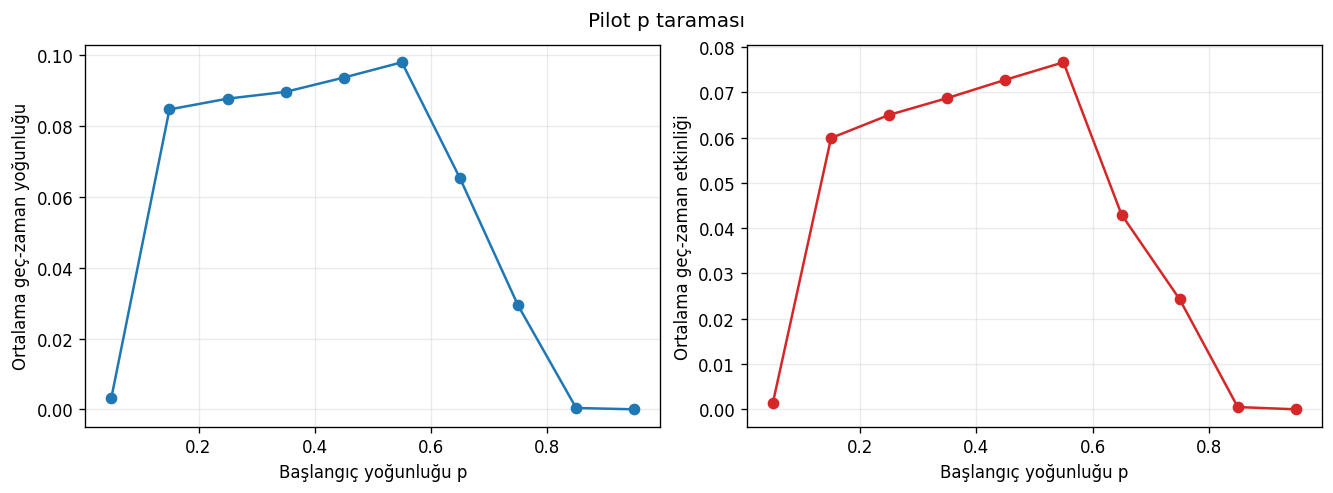

In [15]:
pilot_size = 40
pilot_steps = 120
pilot_runs = 5
pilot_window = 30
pilot_p_values = np.arange(0.05, 1.00, 0.10)

pilot_results = {}
pilot_rng = np.random.default_rng(2026)
start = time.perf_counter()

for p in pilot_p_values:
    rho_samples, activity_samples = run_ensemble(
        pilot_size, p, pilot_steps, pilot_runs, pilot_window, pilot_rng
    )
    pilot_results[float(p)] = {
        "rho_samples": rho_samples,
        "activity_samples": activity_samples,
    }

elapsed = time.perf_counter() - start
print(f"Pilot çalışma süresi: {elapsed:.2f} saniye")

pilot_rho_mean = [pilot_results[float(p)]["rho_samples"].mean() for p in pilot_p_values]
pilot_activity_mean = [
    pilot_results[float(p)]["activity_samples"].mean() for p in pilot_p_values
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(pilot_p_values, pilot_rho_mean, "o-")
axes[0].set(xlabel="Başlangıç yoğunluğu p", ylabel="Ortalama geç-zaman yoğunluğu")
axes[1].plot(pilot_p_values, pilot_activity_mean, "o-", color="tab:red")
axes[1].set(xlabel="Başlangıç yoğunluğu p", ylabel="Ortalama geç-zaman etkinliği")
for ax in axes:
    ax.grid(alpha=0.25)
fig.suptitle("Pilot p taraması")
plt.show()

### Pilot değerlendirmesi

1. Pilot kaç saniye sürdü?
2. Ana deneyin yaklaşık çalışma süresini nasıl tahmin edersin?
3. Hangi $p$ bölgesinde yoğunluk veya etkinlik en büyük görünüyor?
4. Beklenmeyen bir sonuç var mı?
5. Ana deney için $L,T,M$ seçimlerin nedir ve neden?

**Yanıtlarım:**

Pilot benim bilgisayarımda yaklaşık 0.6 saniye sürdü. Ana deneyde hem ızgara daha büyük hem de zaman adımı ve tekrar sayısı daha fazla olduğu için sürenin belirgin şekilde artmasını bekledim. Pilot grafikte yoğunluk ve etkinlik orta $p$ değerlerinde yükseliyor, özellikle yaklaşık $p=0.45-0.55$ civarı dikkat çekiyor. En şaşırtıcı kısım, başlangıç yoğunluğu çok yüksek olduğunda son yoğunluğun artmak yerine hızla düşmesi oldu. Özellikle $p=0.85$ ve $p=0.95$ civarında sistem neredeyse tamamen sönüyor. Ana deney için önerilen $L=60$, $T=300$, $M=20$ değerlerini kullandım çünkü pilot yeterince hızlı çalıştı ve daha fazla tekrarın sonucu daha güvenilir yapacağını düşündüm. Bu yüzden parametreleri küçültmeye gerek görmedim.


## 9. Ana deney: başlangıç yoğunluğu taraması

Önerilen ayarlar:

```python
L = 60
T = 300
M = 20
p = 0.05, 0.10, ..., 0.95
late_window = 50
```

Önce pilotun süresine bak. Bilgisayarın için aşırı yavaşsa gerekçeni yazarak `L` veya `M` değerini azaltabilirsin. Tek bir büyük ızgara yerine bağımsız tekrarları korumaya çalış.

Ana taramayı bilinçli olarak başlatmak için aşağıdaki bayrağı `True` yap.

In [16]:
RUN_MAIN_EXPERIMENT = True  # Pilot başarılı olduktan sonra True yap

main_size = 60
main_steps = 300
main_runs = 20
main_window = 50
main_p_values = np.arange(0.05, 1.00, 0.05)

main_results = {}

if RUN_MAIN_EXPERIMENT:
    main_rng = np.random.default_rng(202605)
    start = time.perf_counter()

    for p in main_p_values:
        rho_samples, activity_samples = run_ensemble(
            main_size, p, main_steps, main_runs, main_window, main_rng
        )
        main_results[float(p)] = {
            "rho_samples": rho_samples,
            "activity_samples": activity_samples,
            "rho_mean": rho_samples.mean(),
            "rho_std": rho_samples.std(ddof=1),
            "activity_mean": activity_samples.mean(),
            "activity_std": activity_samples.std(ddof=1),
        }

    main_elapsed = time.perf_counter() - start
    print(f"Ana deney tamamlandı: {main_elapsed:.2f} saniye")
else:
    print("Ana deney henüz çalıştırılmadı. Hazır olduğunda RUN_MAIN_EXPERIMENT=True yap.")

Ana deney tamamlandı: 12.54 saniye


## 10. Ana sonuç şekilleri

Hata çubukları örneklem standart sapmasını, yani bağımsız başlangıçlar arasındaki değişkenliği gösterir. Bunlar ortalamanın standart hatası değildir.

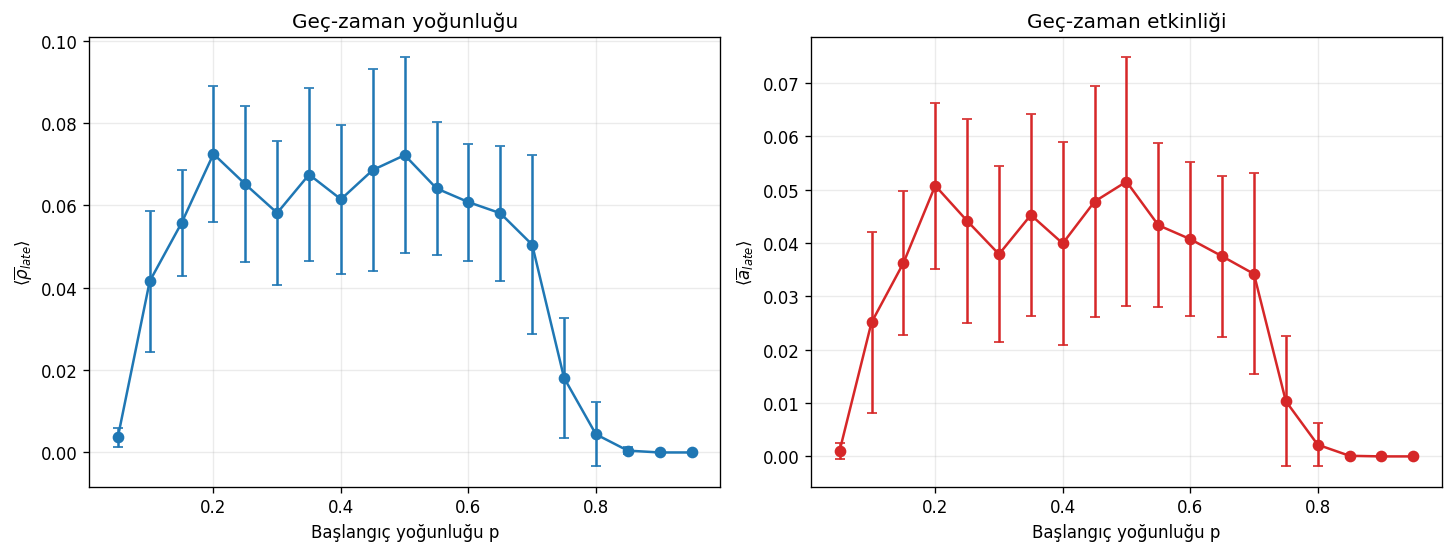

In [17]:
if main_results:
    rho_mean = np.array([main_results[float(p)]["rho_mean"] for p in main_p_values])
    rho_std = np.array([main_results[float(p)]["rho_std"] for p in main_p_values])
    activity_mean = np.array([
        main_results[float(p)]["activity_mean"] for p in main_p_values
    ])
    activity_std = np.array([
        main_results[float(p)]["activity_std"] for p in main_p_values
    ])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    axes[0].errorbar(main_p_values, rho_mean, yerr=rho_std, fmt="o-", capsize=3)
    axes[0].set(
        xlabel="Başlangıç yoğunluğu p",
        ylabel=r"$\langle\overline{\rho}_{late}\rangle$",
        title="Geç-zaman yoğunluğu",
    )
    axes[1].errorbar(
        main_p_values, activity_mean, yerr=activity_std,
        fmt="o-", capsize=3, color="tab:red"
    )
    axes[1].set(
        xlabel="Başlangıç yoğunluğu p",
        ylabel=r"$\langle\overline{a}_{late}\rangle$",
        title="Geç-zaman etkinliği",
    )
    for ax in axes:
        ax.grid(alpha=0.25)
    plt.show()
else:
    print("Önce ana deneyi çalıştır.")

### Ana sonuç tablosu

| $p$ | Ortalama geç yoğunluk | Yoğunluk std | Ortalama geç etkinlik | Etkinlik std | Yorum |
|---:|---:|---:|---:|---:|---|
| 0.05 | 0.00368 | 0.00231 | 0.00106 | 0.00151 | Sistem çoğunlukla sönüyor. |
| 0.15 | 0.05573 | 0.01288 | 0.03622 | 0.01356 | Canlı yapılar belirginleşiyor. |
| 0.25 | 0.06511 | 0.01895 | 0.04413 | 0.01912 | Yoğunluk ve etkinlik yüksek. |
| 0.35 | 0.06748 | 0.02096 | 0.04524 | 0.01893 | Orta yoğunlukta aktif bir rejim var. |
| 0.50 | 0.07219 | 0.02383 | 0.05149 | 0.02335 | Etkinlik ölçtüğüm değerler içinde en yüksek. |
| 0.70 | 0.05044 | 0.02177 | 0.03419 | 0.01883 | Aşırı kalabalığın etkisi görülmeye başlıyor. |
| 0.95 | 0.00000 | 0.00000 | 0.00000 | 0.00000 | Sistem tamamen sönüyor. |

### Ana sorulara yanıtlarım

1. İlişki monoton değil. $p$ arttıkça geç-zaman yoğunluğu önce yükseliyor ama yüksek $p$ değerlerinde tekrar düşüyor.
2. Bütün taramada en yüksek ortalama geç-zaman yoğunluğunu yaklaşık $p=0.20$'de ölçtüm ve değer yaklaşık 0.07247 oldu.
3. En yüksek ortalama geç-zaman etkinliği $p=0.50$'de, yaklaşık 0.05149 çıktı.
4. Yoğunluk standart sapmasının en büyük olduğu değer $p=0.45$ ve standart sapma yaklaşık 0.02458. Bu bölgede farklı rastgele başlangıçların sonuçları birbirinden daha fazla ayrılıyor.
5. Evet. Özellikle $p=0.70$'ten sonra düşüş hızlanıyor ve $p=0.95$'te geç-zaman yoğunluğu sıfır oluyor. Bu, çok kalabalık başlangıçların aşırı komşuluk nedeniyle erken çökebildiği tahminimle uyumlu.
6. Ortalama yoğunluk, etkinlik ve standart sapmalar doğrudan simülasyondan ölçtüğüm değerler. “Orta bölgede daha aktif bir rejim var” veya “aşırı kalabalık çöküşe yol açıyor” gibi cümleler ise bu ölçümlere dayanarak yaptığım yorumlar.


## 11. Temsilî zaman serileri ve görüntüler

Ensemble grafikleri tipik davranışı özetler, tek tek yörüngeleri göstermez. $p=0.10,0.35,0.80$ için aynı tohumla örnek yörüngeler çizelim.

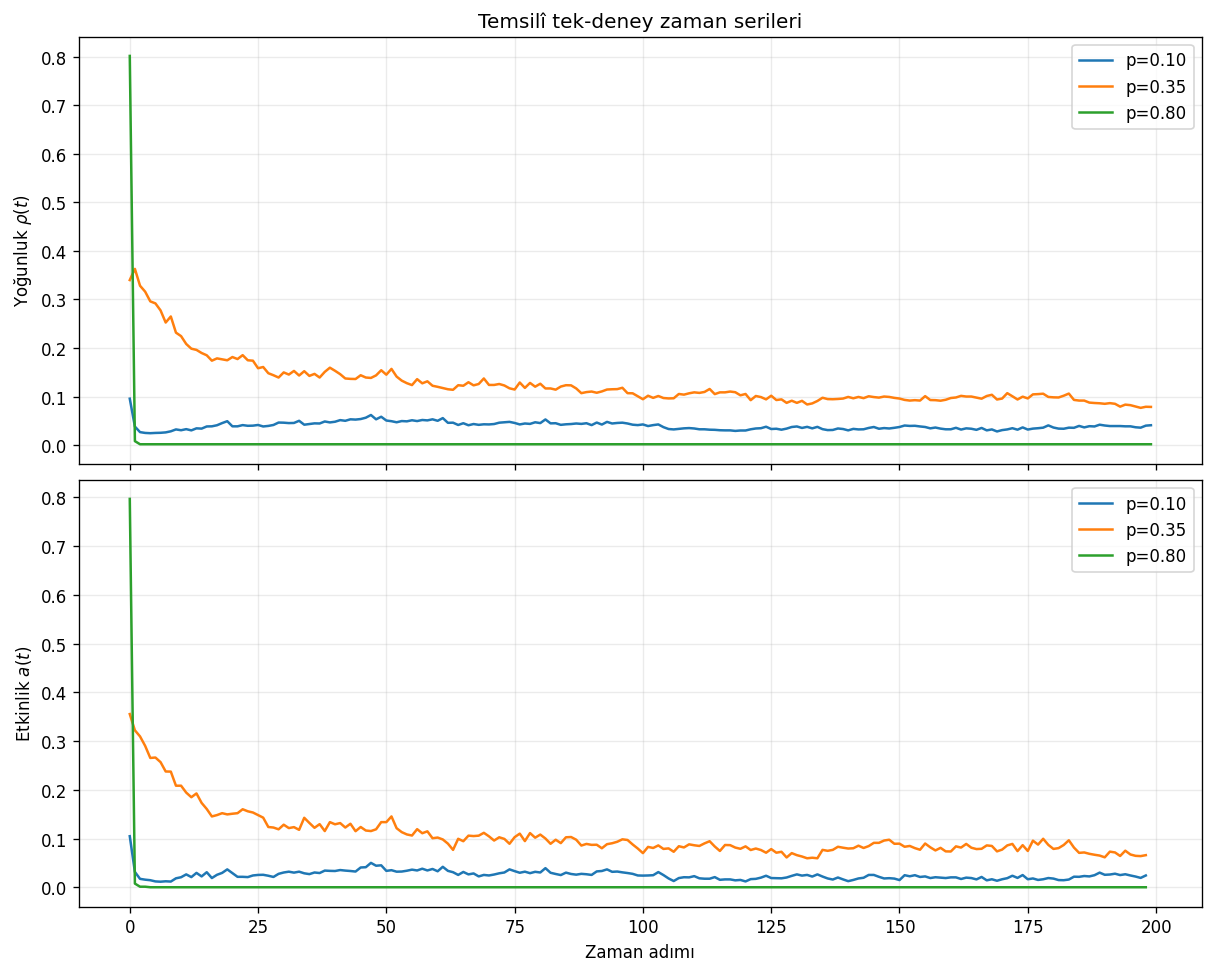

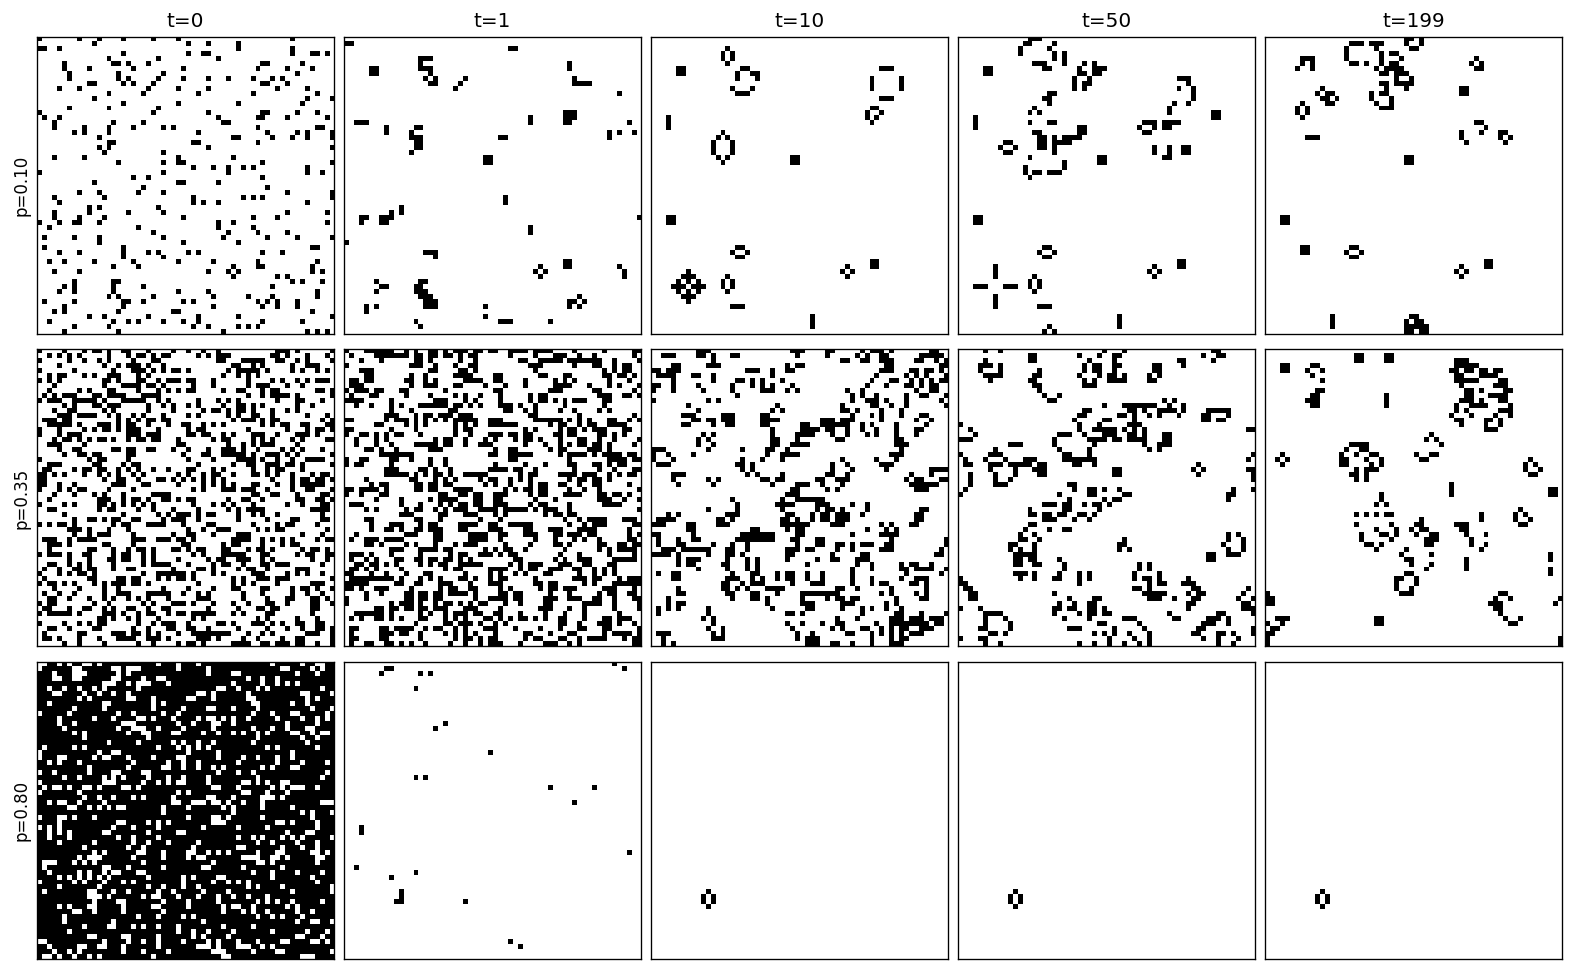

In [18]:
example_p_values = [0.10, 0.35, 0.80]
example_steps = 200
example_size = 60
example_histories = {}

for p in example_p_values:
    initial = random_grid(
        example_size, p, np.random.default_rng(1000 + int(100 * p))
    )
    example_histories[p] = simulate_life(initial, example_steps)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, constrained_layout=True)
for p, history in example_histories.items():
    axes[0].plot(density_time_series(history), label=f"p={p:.2f}")
    axes[1].plot(activity_time_series(history), label=f"p={p:.2f}")

axes[0].set(ylabel=r"Yoğunluk $\rho(t)$", title="Temsilî tek-deney zaman serileri")
axes[1].set(xlabel="Zaman adımı", ylabel=r"Etkinlik $a(t)$")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
plt.show()

frames = [0, 1, 10, 50, 199]
fig, axes = plt.subplots(len(example_p_values), len(frames), figsize=(13, 8), constrained_layout=True)
for row, p in enumerate(example_p_values):
    for col, t in enumerate(frames):
        ax = axes[row, col]
        ax.imshow(example_histories[p][t], interpolation="nearest", vmin=0, vmax=1)
        if row == 0:
            ax.set_title(f"t={t}")
        if col == 0:
            ax.set_ylabel(f"p={p:.2f}")
        ax.set_xticks([])
        ax.set_yticks([])
plt.show()

### Temsilî yörüngeleri yorumla

**Yanıtlarım:**

Üç örneği karşılaştırınca ilk birkaç adımda en hızlı yoğunluk kaybı $p=0.80$ başlangıcında görülüyor. Bunun nedeni başlangıçta çok fazla canlı hücrenin birbirine komşu olması ve aşırı kalabalık yüzünden ölmesi gibi görünüyor. Daha düşük ve orta yoğunluklarda sistem tamamen aynı şekilde davranmıyor, bazı küçük canlı kümeler daha uzun süre kalabiliyor. Uzun zamanda tamamen sabit kalan küçük yapılar ve zamanla değişmeye devam eden küçük bölgeler seçilebiliyor. Tek örnek yörüngeler genel olarak ensemble sonucundaki eğilimle uyumlu, fakat birebir aynı değeri vermiyor. Bu normal çünkü her rastgele başlangıç farklı. Bu yüzden tek bir ilginç görüntüyü seçip sistemin “tipik davranışı” demek yanıltıcı olabilir. Ensemble ortalaması burada daha güvenilir çünkü birçok bağımsız başlangıcı birlikte değerlendiriyor.


## 12. Mini araştırma - En değişken $p$ değerini incele

Ana deneyde yoğunluk standart sapması en büyük olan $p$'yi bul. Sonra bu $p$ için yeni bir ensemble çalıştır ve en düşük ile en yüksek geç-zaman yoğunluğuna sahip iki yörüngeyi karşılaştır.

Bu araştırma şu soruyu yanıtlar:

> **Aynı kontrol edilen başlangıç yoğunluğu neden çok farklı sonuçlar üretebilir?**

En büyük yoğunluk değişkenliği: p=0.45


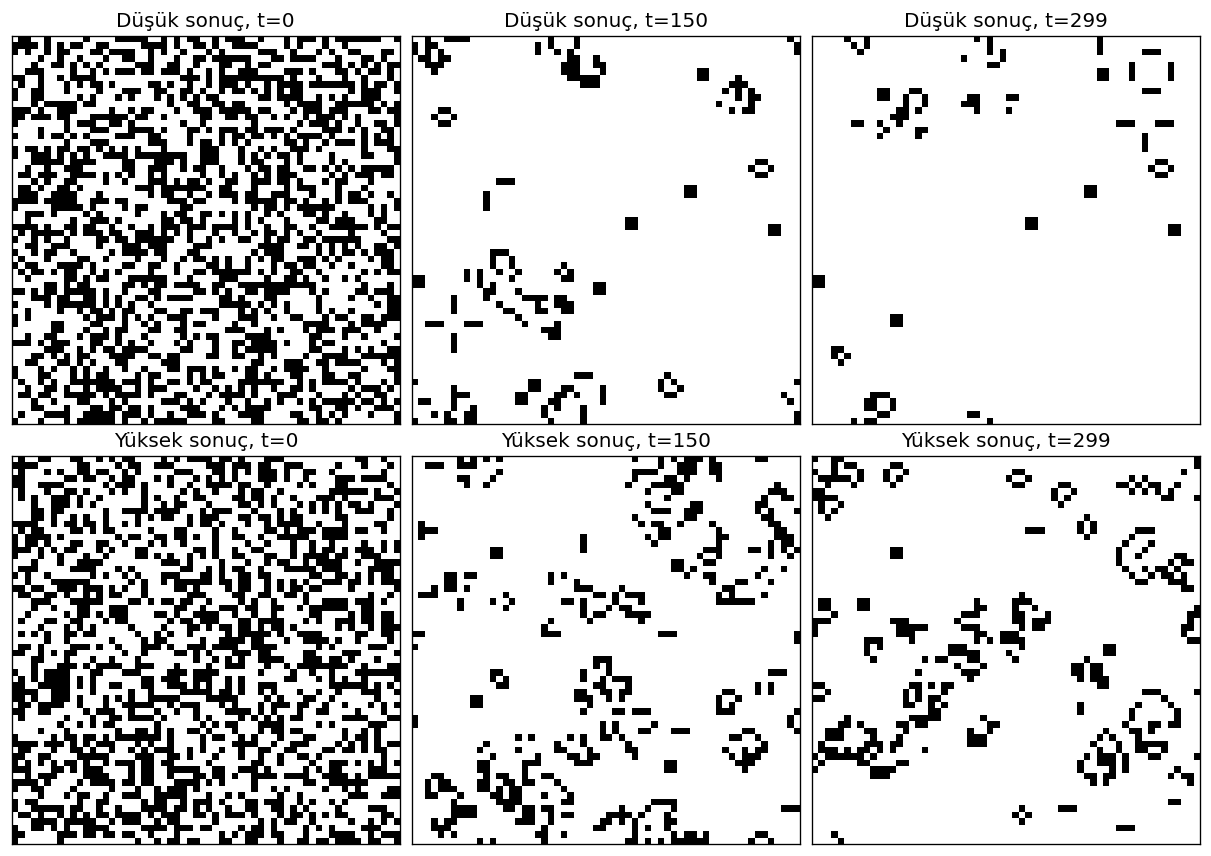

En düşük geç yoğunluk: 0.039461111111111113
En yüksek geç yoğunluk: 0.09514444444444445


In [19]:
if main_results:
    most_variable_p = max(
        main_p_values,
        key=lambda p: main_results[float(p)]["rho_std"],
    )
    print(f"En büyük yoğunluk değişkenliği: p={most_variable_p:.2f}")

    investigation_rng = np.random.default_rng(505)
    investigation_histories = []
    investigation_late_rho = []

    for run in range(20):
        initial = random_grid(main_size, most_variable_p, investigation_rng)
        history = simulate_life(initial, main_steps)
        investigation_histories.append(history)
        investigation_late_rho.append(
            late_time_average(density_time_series(history), main_window)
        )

    low_index = int(np.argmin(investigation_late_rho))
    high_index = int(np.argmax(investigation_late_rho))

    fig, axes = plt.subplots(2, 3, figsize=(10, 7), constrained_layout=True)
    for row, (index, label) in enumerate([
        (low_index, "Düşük sonuç"),
        (high_index, "Yüksek sonuç"),
    ]):
        history = investigation_histories[index]
        for col, t in enumerate([0, main_steps // 2, main_steps - 1]):
            axes[row, col].imshow(history[t], interpolation="nearest", vmin=0, vmax=1)
            axes[row, col].set_title(f"{label}, t={t}")
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
    plt.show()

    print("En düşük geç yoğunluk:", investigation_late_rho[low_index])
    print("En yüksek geç yoğunluk:", investigation_late_rho[high_index])
else:
    print("Mini araştırma için önce ana deneyi çalıştır.")

### Mini araştırma sonucu

**Sonucum:**

En büyük yoğunluk değişkenliğini $p=0.45$'te buldum. Bu $p$ değeri aynı olsa da iki başlangıç ızgarasının gerçek başlangıç yoğunlukları tam olarak aynı olmak zorunda değil, ikisi de aynı olasılıktan rastgele üretiliyor. Yeni 20 deney içinde en düşük geç-zaman yoğunluğu yaklaşık **0.03946**, en yüksek ise yaklaşık **0.09514** çıktı. Aradaki fark oldukça büyük olduğu için aynı $p$ değerinin tek başına sonucu tamamen belirlemediğini gördüm. Game of Life deterministik olsa da başlangıçtaki küçük yapısal farklar zaman içinde farklı desenlere dönüşebiliyor. Bu nedenle farkı yalnızca ölçüm gürültüsü olarak görmüyorum. Daha fazla tekrar yaparsam standart sapmanın tahmini daha kararlı hale gelir ve birkaç sıra dışı örneğin etkisi azalır. Bence bu deney, neden tek bir simülasyon yerine ensemble kullanmamız gerektiğini en açık gösteren kısımlardan biri oldu.


## 13. Bilimsel sınırlamalar

Bu deneyde sonuçları yorumlarken birkaç sınır olduğunu düşünüyorum. İlk olarak $T=300$ sonlu bir süre, yani sistemin sonsuz zamandaki davranışını kesin olarak göstermiyor. Aynı şekilde $60\times60$ periyodik ızgara da sonsuz bir düzlem değil. Her $p$ için 20 tekrar yaptım fakat bütün olası rastgele başlangıçları incelemek mümkün değil. Son 50 adımın ortalamasını kullandım, farklı bir pencere seçilirse sayılar biraz değişebilir. Rastgele tohum kullanmam deneyi tekrar üretilebilir yapıyor ama başka tohumlarla da kontrol etmek daha güçlü olurdu. Ayrıca yoğunluk ve etkinlik bana genel davranışı gösteriyor fakat oluşan desenlerin şekillerini doğrudan ölçmüyor.

### Kısa sorulara yanıtlarım

- **Standart sapma ile standart hata arasındaki fark nedir?** Standart sapma farklı deney sonuçlarının ne kadar yayıldığını gösteriyor. Standart hata ise hesapladığım ortalamanın ne kadar belirsiz olduğunu gösterir ve yaklaşık $s/\sqrt{M}$ ile bulunur.
- **Hata çubuğunda hangisini kullandın ve neden?** Bu notebookta standart sapma kullandım çünkü bağımsız başlangıçlar arasındaki değişkenliği göstermek istedim.
- **En yüksek geç-zaman yoğunluğu olan $p$, en yüksek etkinliği de vermek zorunda mı?** Hayır. Benim sonuçlarımda en yüksek yoğunluk yaklaşık $p=0.20$'de, en yüksek etkinlik ise $p=0.50$'de çıktı.
- **Sonuçları “faz geçişi” olarak adlandırmak için mevcut kanıt yeterli mi?** Bence yeterli değil. Bunun için daha büyük ızgaralar, daha uzun süreler ve sistem boyutuna göre değişimin ayrıca incelenmesi gerekir. Şimdilik belirgin bir davranış değişimi veya farklı rejimler olduğunu söylemek daha doğru.


## 14. Sonuç ve haftalık kontrol noktası

### Çıkış sorusu

Tek bir Game of Life simülasyonu sadece belirli bir başlangıç durumunun nasıl geliştiğini gösteriyor. Fakat rastgele başlangıç kullandığımızda aynı başlangıç yoğunluğu $p$ için bile sonuçlar değişebiliyor. Bu yüzden her $p$ değerinde bağımsız tekrarlar yapmak daha anlamlı oluyor. Her deneyde sadece son kareye bakmak yerine son bölümün geç-zaman ortalamasını aldım. Sonra bu değerlerin örneklem ortalamasını hesaplayarak o $p$ için daha tipik bir davranış elde etmeye çalıştım. Standart sapma ise farklı başlangıçların sonuçlarının ne kadar değiştiğini gösterdi. Özellikle $p=0.45$ civarında bu değişkenliğin yüksek olduğunu gördüm. Tek bir simülasyon seçseydim bu çeşitliliği kaçırabilirdim. Yine de kullandığım süre sonlu olduğu için bunların sonsuz-zaman sonucu olduğunu söyleyemem. Bu nedenle ensemble deneyi bana daha güçlü bir istatistiksel sonuç veriyor ama yine de modelin ve simülasyon süresinin sınırlarını dikkate almak gerekiyor.

### 6. haftaya köprü

Bu hafta standart Life kuralını sabit tutup yalnızca başlangıcı değiştirdim. 6. haftada dinamiğin içine rastgele ölüm olasılığı $\mu$ eklendiğinde, bugünkü ensemble yöntemini tekrar kullanarak etkinliğin nasıl değiştiğini incelemek istiyorum.

### Profesörle tartışmak istediğim sorular

1. $p=0.45$ civarında standart sapmanın daha yüksek çıkması, gerçekten özel bir davranış bölgesine işaret ediyor olabilir mi? Bunu test etmek için sistem boyutunu $L=40,60,80,100$ gibi değiştirip tepenin yerinin veya yüksekliğinin değişmesine bakmak mantıklı olur mu?
2. Yoğunluk ve etkinliğe ek olarak oluşan kümelerin boyutunu veya ömrünü ölçmek, sistemdeki yapısal değişimleri daha iyi göstermemizi sağlar mı? Eğer evetse 7. haftadaki bağımsız araştırmada hangi ölçüm en faydalı olur?

### GitHub teslimi

Dosya adı: `05_random_initial_conditions.ipynb`

Önerilen kayıt mesajı: `5. Hafta: Rastgele başlangıç koşulları`

Ana deney açık durumda ve notebook baştan sona çalıştırıldığında altı test, pilot deney, ana tarama ve mini araştırma birlikte çalışıyor.
